In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import mne
import ipywidgets as widgets
from IPython.display import display
from mne.filter import filter_data as _fd
import warnings
warnings.filterwarnings("ignore")

save_dir = Path("/Users/elizabethkaplan/Desktop/SS2_Results/time_resolved")

#load in time resolved data files for each subj
all_subjects = {}
for path in sorted(save_dir.glob("*_time_resolved.npz")):
    subj_id = path.name.replace("_time_resolved.npz", "")
    d = np.load(path, allow_pickle=True)
    all_subjects[subj_id] = {k: d[k] for k in d.files}
    all_subjects[subj_id]["window_stages"] = list(all_subjects[subj_id]["window_stages"])
    print(f"Loaded {subj_id}: {len(all_subjects[subj_id]['t_centers'])} windows")

Loaded 01-02-0001: 115821 windows
Loaded 01-02-0002: 140061 windows
Loaded 01-02-0003: 147037 windows
Loaded 01-02-0004: 112013 windows
Loaded 01-02-0005: 124973 windows
Loaded 01-02-0006: 115957 windows
Loaded 01-02-0007: 113205 windows
Loaded 01-02-0008: 107381 windows
Loaded 01-02-0009: 119333 windows
Loaded 01-02-0010: 103717 windows
Loaded 01-02-0011: 101733 windows
Loaded 01-02-0012: 126117 windows
Loaded 01-02-0013: 145485 windows
Loaded 01-02-0014: 112701 windows
Loaded 01-02-0015: 116453 windows
Loaded 01-02-0016: 113357 windows
Loaded 01-02-0017: 113365 windows
Loaded 01-02-0018: 118213 windows


In [2]:
## Load event annotations (onset + duration) for all subjects

#where annotations csv lives 
annot_dir = Path("/Users/elizabethkaplan/Desktop/SS2_Results/New")

all_spindles = []
all_kcs      = []

#use raw annotation file -> no mapping 
for subj_id in all_subjects.keys():
    annot_path = annot_dir / subj_id / "cleaned" / f"{subj_id}_annotations.csv"
    if not annot_path.exists():
        print(f"Missing: {annot_path}")
        continue
    df = pd.read_csv(annot_path)
    
    spindles = df[df["description"].str.contains("spindle", case=False, na=False)].copy()
    kcs      = df[df["description"].str.contains("kcomplex", case=False, na=False)].copy()
    
    spindles["subject"] = subj_id
    kcs["subject"]      = subj_id
    
    all_spindles.append(spindles[["subject", "onset_s", "duration_s"]])
    all_kcs.append(kcs[["subject", "onset_s", "duration_s"]])

spindle_df = pd.concat(all_spindles, ignore_index=True)
kc_df      = pd.concat(all_kcs,      ignore_index=True)

Total spindles: 10889  |  duration: 0.34–2.22s  mean=0.84s
Total KCs:      11391  |  duration: 0.07–1.49s  mean=0.72s


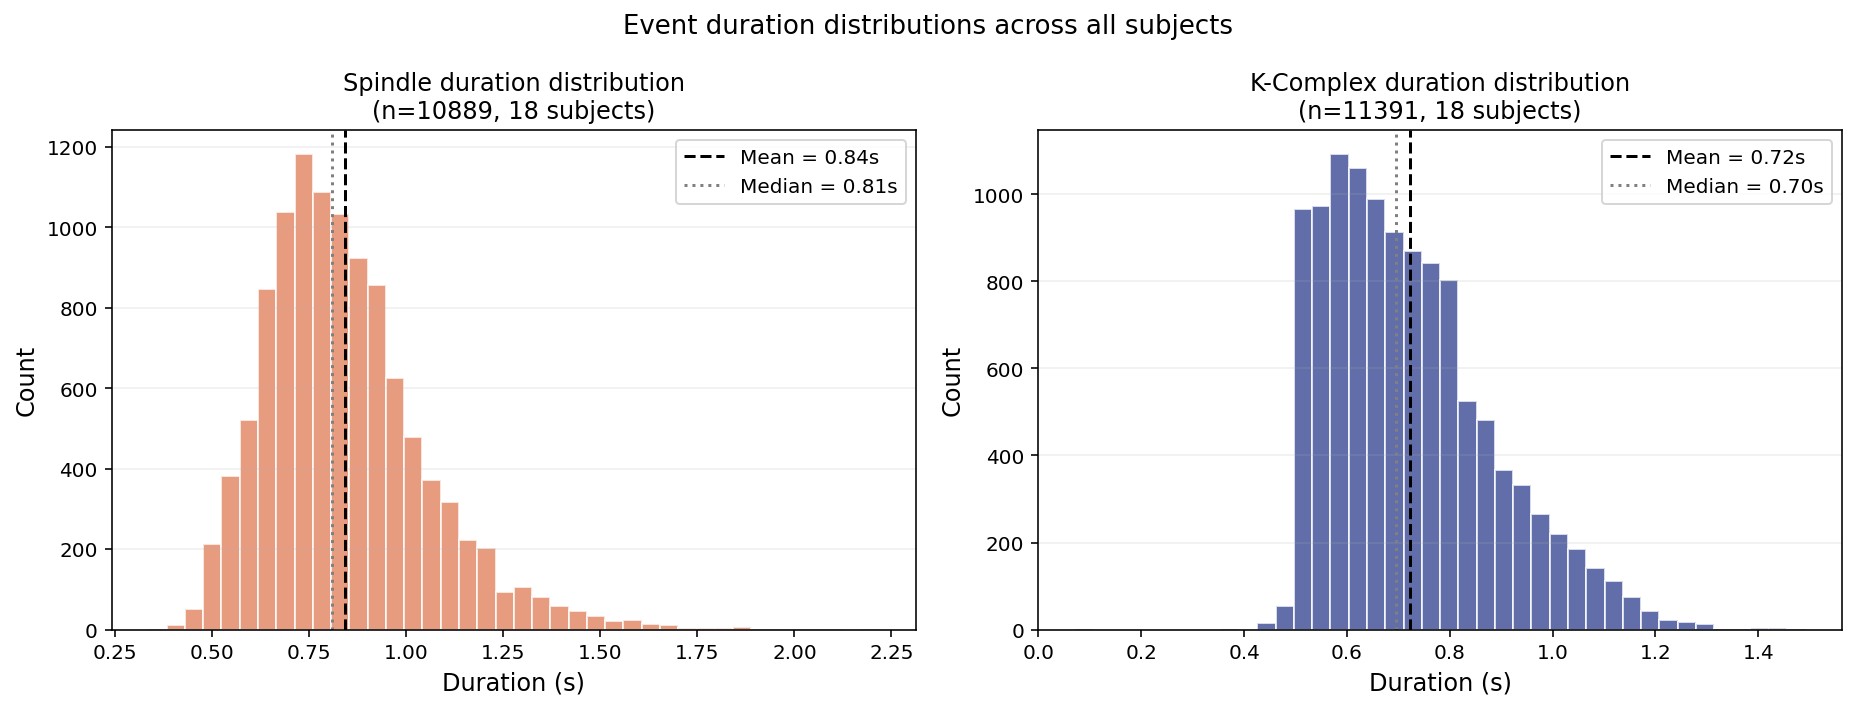

In [3]:
## Duration distributions: spindles and KCs across duration bins

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, label, color in zip(
    axes,
    [spindle_df, kc_df],
    ["Spindle", "K-Complex"],
    ["#e07b54", "#2c3e8c"],
):
    durations = df["duration_s"].dropna()
    #plot distributions with mean and median 
    ax.hist(durations, bins=40, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(durations.mean(),   color="k",    linestyle="--", linewidth=1.5,
               label=f"Mean = {durations.mean():.2f}s")
    ax.axvline(durations.median(), color="gray", linestyle=":",  linewidth=1.5,
               label=f"Median = {durations.median():.2f}s")
    ax.set_xlabel("Duration (s)", fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.set_title(f"{label} duration distribution\n(n={len(durations)}, {df['subject'].nunique()} subjects)",
                 fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.show()

In [4]:
## Characterize KC / Spindle temporal relationship 

#classify events based on the surrounding events within 3 sec +- 
relation_window = 3.0   # 3 sec

all_relation_rows = []

for subj_id, d in all_subjects.items():
    kc_onsets      = d["kc_onsets"]
    spindle_onsets = d["spindle_onsets"]

    # classify each KC - before/after or isolated 
    for onset in kc_onsets:
        diffs = spindle_onsets - onset
        before = diffs[(diffs < 0) & (diffs >= -relation_window)]
        after  = diffs[(diffs > 0) & (diffs <=  relation_window)]

        if len(after) > 0:
            category = "kc_before_spindle"
        elif len(before) > 0:
            category = "kc_after_spindle"
        else:
            category = "kc_isolated"

        all_relation_rows.append({
            "subject":    subj_id,
            "event_type": "kc",
            "onset":      onset,
            "category":   category,
        })

    # classify spindles - before/after or isolated 
    for onset in spindle_onsets:
        diffs = kc_onsets - onset
        before = diffs[(diffs < 0) & (diffs >= -relation_window)]
        after  = diffs[(diffs > 0) & (diffs <=  relation_window)]

        if len(after) > 0:
            category = "spindle_before_kc"
        elif len(before) > 0:
            category = "spindle_after_kc"
        else:
            category = "spindle_isolated"

        all_relation_rows.append({
            "subject":    subj_id,
            "event_type": "spindle",
            "onset":      onset,
            "category":   category,
        })

relation_df = pd.DataFrame(all_relation_rows)

#print("Event counts by category:")
#print(relation_df["category"].value_counts())
#print(f"\nTotal KCs:      {(relation_df['event_type']=='kc').sum()}")
#print(f"Total spindles: {(relation_df['event_type']=='spindle').sum()}")

Event counts by category:
category
kc_isolated          8732
spindle_isolated     8489
kc_before_spindle    1403
spindle_before_kc    1361
kc_after_spindle     1256
spindle_after_kc     1039
Name: count, dtype: int64

Total KCs:      11391
Total spindles: 10889


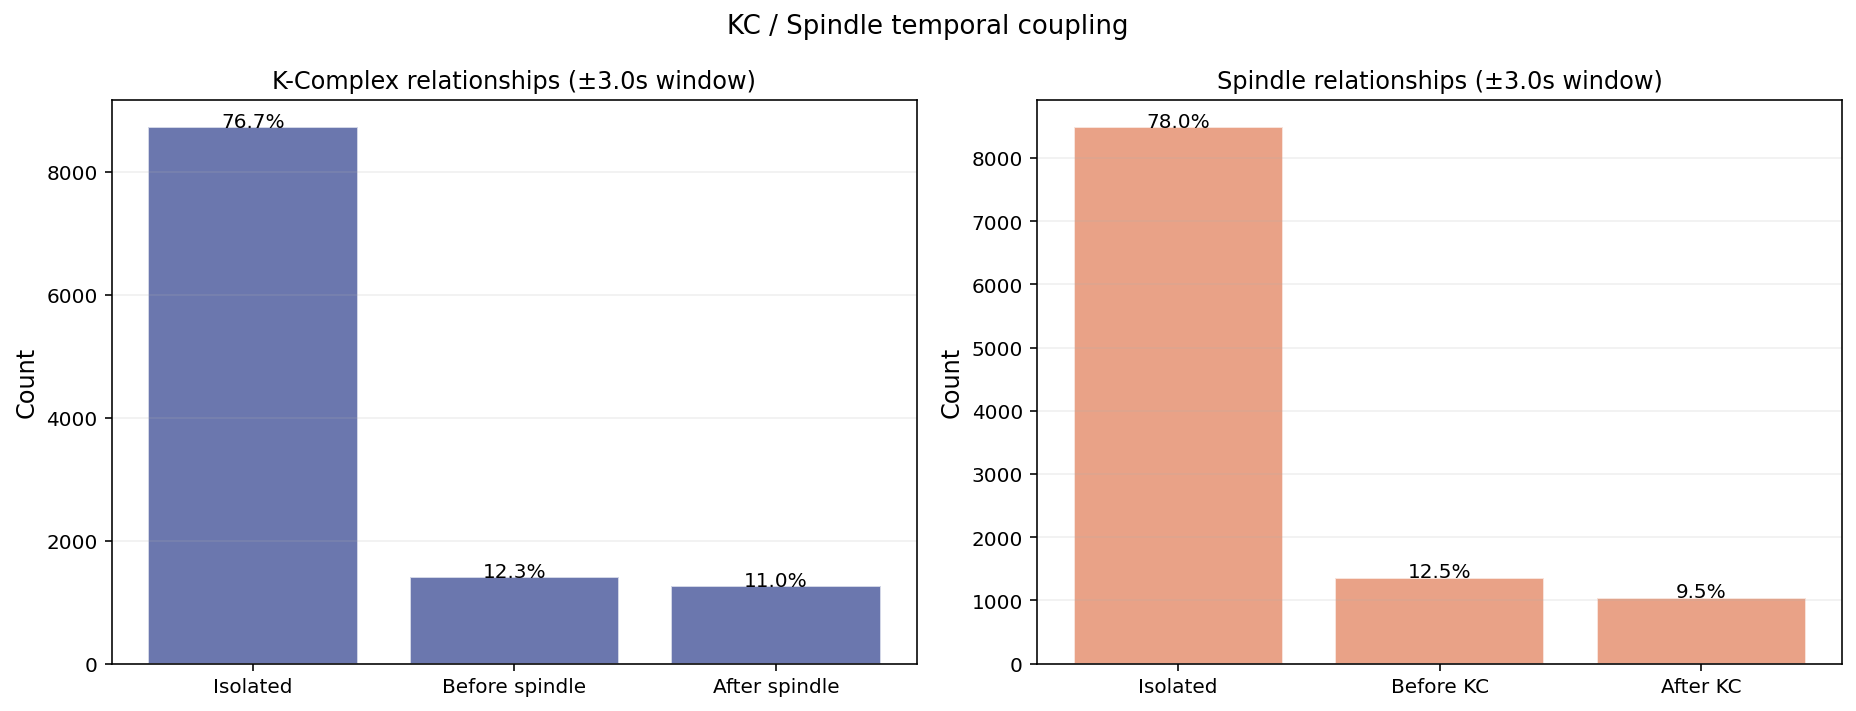

In [5]:
## Plot distributions across groups (before spindle, isolated, etc) 

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

kc_cats      = ["kc_isolated", "kc_before_spindle", "kc_after_spindle"]
spindle_cats = ["spindle_isolated", "spindle_before_kc", "spindle_after_kc"]
kc_labels      = ["Isolated", "Before spindle", "After spindle"]
spindle_labels = ["Isolated", "Before KC", "After KC"]

for ax, event_type, cats, labels, color in zip(
    axes,
    ["kc", "spindle"],
    [kc_cats, spindle_cats],
    [kc_labels, spindle_labels],
    ["#2c3e8c", "#e07b54"],
):
    sub = relation_df[relation_df["event_type"] == event_type]
    counts = [sub[sub["category"] == c].shape[0] for c in cats]
    pcts   = [100 * c / sum(counts) for c in counts]

    bars = ax.bar(labels, counts, color=color, alpha=0.7, edgecolor="white")
    ax.set_ylabel("Count", fontsize=12)
    ax.set_title(f"{'K-Complex' if event_type=='kc' else 'Spindle'} relationships "
                 f"(±{relation_window}s window)", fontsize=12)
    ax.grid(True, alpha=0.2, axis="y")

    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{pct:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

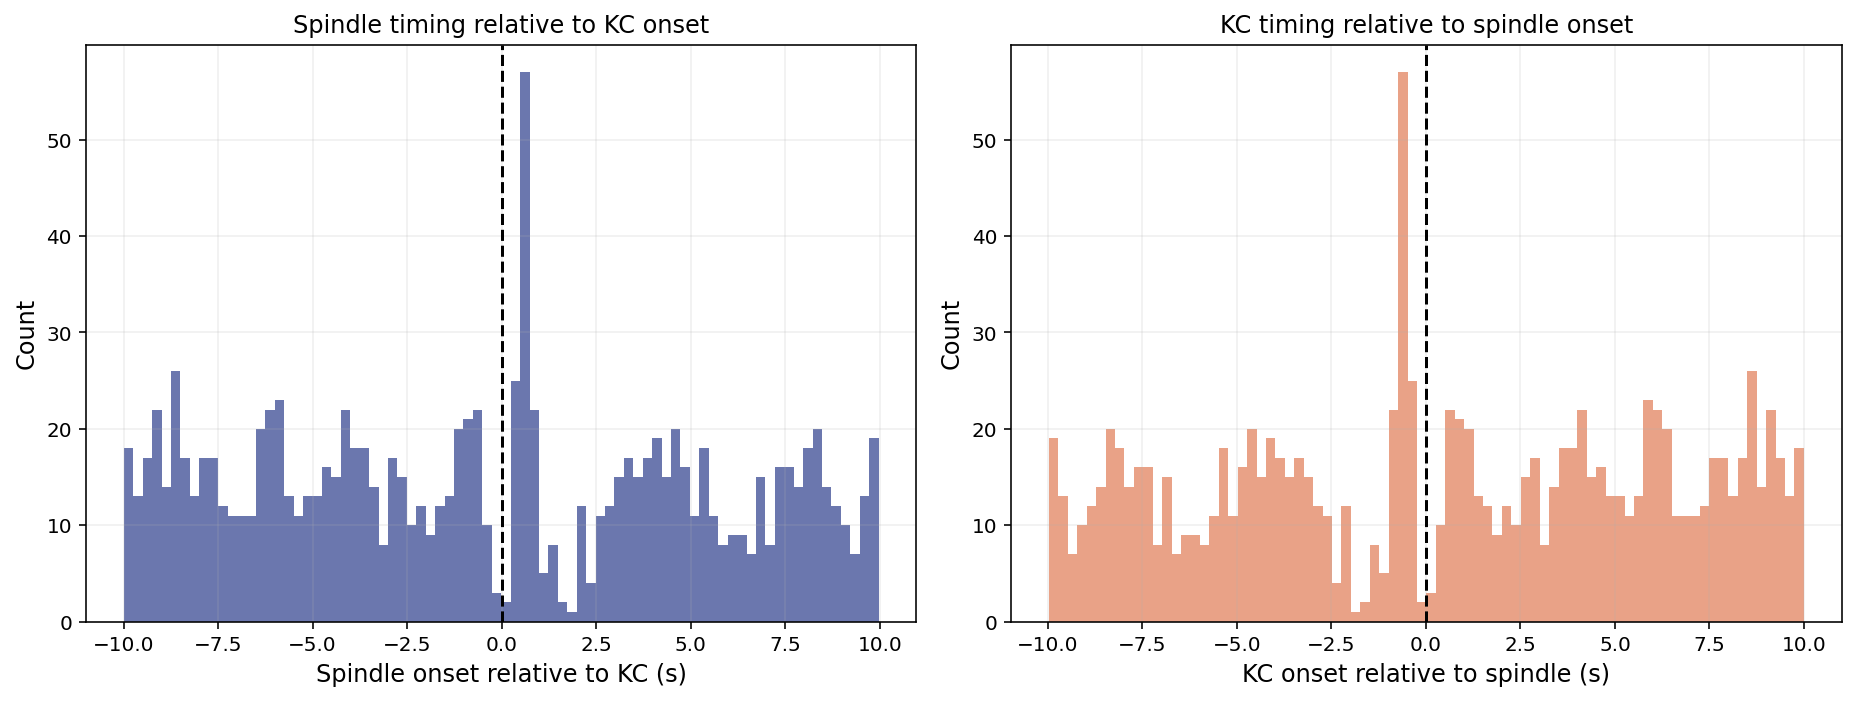

In [22]:
## Plot cross-event timing: when do spindles occur relative to KCs?

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for subj_id, d in all_subjects.items():
    kc_onsets      = d["kc_onsets"]
    spindle_onsets = d["spindle_onsets"]

    # for each KC, find nearest spindle and record lag
    kc_to_spindle_lags = []
    for onset in kc_onsets:
        diffs = spindle_onsets - onset
        nearby = diffs[np.abs(diffs) <= 10.0]
        kc_to_spindle_lags.extend(nearby.tolist())

    spindle_to_kc_lags = []
    for onset in spindle_onsets:
        diffs = kc_onsets - onset
        nearby = diffs[np.abs(diffs) <= 10.0]
        spindle_to_kc_lags.extend(nearby.tolist())

axes[0].hist(kc_to_spindle_lags, bins=80, color="#2c3e8c", alpha=0.7, edgecolor="none")
axes[0].axvline(0, color="k", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Spindle onset relative to KC (s)", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_title("Spindle timing relative to KC onset", fontsize=12)
axes[0].grid(True, alpha=0.2)

axes[1].hist(spindle_to_kc_lags, bins=80, color="#e07b54", alpha=0.7, edgecolor="none")
axes[1].axvline(0, color="k", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("KC onset relative to spindle (s)", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)
axes[1].set_title("KC timing relative to spindle onset", fontsize=12)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [7]:
## Detect spindle trains

#train defined as events occuring within 6 seconds of one another *
train_window = 6.0
all_train_rows = []

for subj_id, d in all_subjects.items():
    spindle_onsets = np.sort(d["spindle_onsets"])
    
    if len(spindle_onsets) < 2:
        continue

    # assign each spindle to a train, then check for other spindles to group with it if meet temporal dynamics requirement (i.e.
    # within train_window 
    train_id   = 0
    train_ids  = [0]
    train_sizes = []

    for i in range(1, len(spindle_onsets)):
        gap = spindle_onsets[i] - spindle_onsets[i-1]
        if gap <= train_window:
            train_ids.append(train_id)
        else:
            train_id += 1
            train_ids.append(train_id)

    train_ids = np.array(train_ids)
    n_trains  = train_id + 1

    for tid in range(n_trains):
        members = np.where(train_ids == tid)[0]
        all_train_rows.append({
            "subject":       subj_id,
            "train_id":      tid,
            "n_spindles":    len(members),
            "onset":         spindle_onsets[members[0]],
            "offset":        spindle_onsets[members[-1]],
            "duration":      spindle_onsets[members[-1]] - spindle_onsets[members[0]],
            "is_train":      len(members) > 1,
        })

train_df = pd.DataFrame(all_train_rows)

#print(f"Total spindle trains (groups): {len(train_df)}")
#print(f"Isolated spindles (n=1):       {(train_df['n_spindles']==1).sum()}  "
 #     f"({100*(train_df['n_spindles']==1).mean():.1f}%)")
#print(f"Actual trains (n≥2):           {(train_df['n_spindles']>1).sum()}  "
#      f"({100*(train_df['n_spindles']>1).mean():.1f}%)")
#print(f"\nTrain size distribution:")
#print(train_df['n_spindles'].value_counts().sort_index())
#print(f"\nMean spindles per train (trains only): "
#      f"{train_df[train_df['is_train']]['n_spindles'].mean():.2f}")
#print(f"Max spindles in one train: {train_df['n_spindles'].max()}")

Total spindle trains (groups): 7497
Isolated spindles (n=1):       5362  (71.5%)
Actual trains (n≥2):           2135  (28.5%)

Train size distribution:
n_spindles
1     5362
2     1401
3      438
4      168
5       66
6       40
7       13
8        4
9        4
10       1
Name: count, dtype: int64

Mean spindles per train (trains only): 2.59
Max spindles in one train: 10


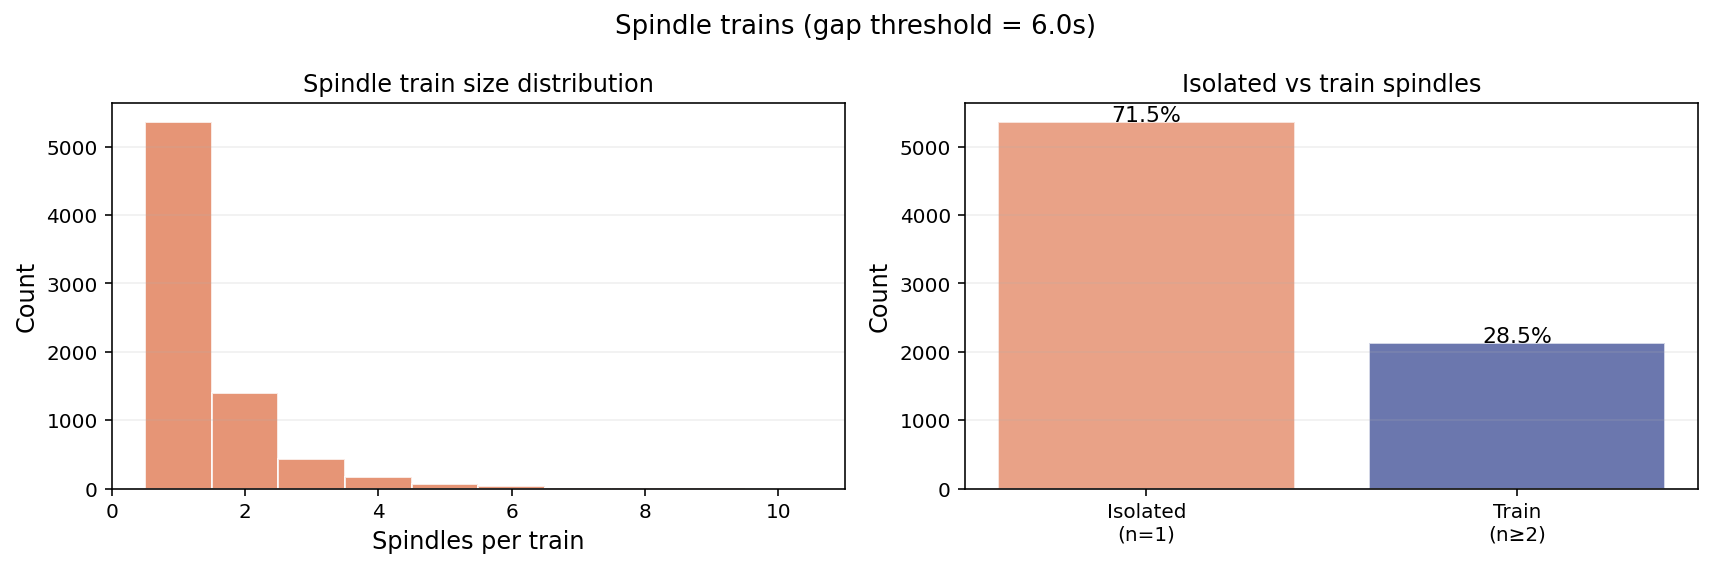

In [8]:
## Plot train info distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histogram of train sizes
axes[0].hist(train_df["n_spindles"], bins=range(1, train_df["n_spindles"].max()+2),
             color="#e07b54", alpha=0.8, edgecolor="white", align="left")
axes[0].set_xlabel("Spindles per train", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_title("Spindle train size distribution", fontsize=12)
axes[0].grid(True, alpha=0.2, axis="y")

# isolated vs train
counts = [
    (train_df["n_spindles"] == 1).sum(),
    (train_df["n_spindles"] > 1).sum(),
]
axes[1].bar(["Isolated\n(n=1)", "Train\n(n≥2)"], counts,
            color=["#e07b54", "#2c3e8c"], alpha=0.7, edgecolor="white")
for i, (bar, count) in enumerate(zip(axes[1].patches, counts)):
    pct = 100 * count / sum(counts)
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f"{pct:.1f}%", ha="center", fontsize=11)
axes[1].set_ylabel("Count", fontsize=12)
axes[1].set_title("Isolated vs train spindles", fontsize=12)
axes[1].grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.show()

In [9]:
## Extract isolated events; event free on both sides
#investigate aperiodic dynamics in these event-free time points surrounding event 

isolation_window = 10.0   
pre_sec  = 10.0
post_sec = 10.0

step_sec = float(np.median(np.diff(all_subjects["01-02-0001"]["t_centers"])))
n_bins  = int((pre_sec + post_sec) / step_sec)
t_event = np.linspace(-pre_sec, post_sec, n_bins)

kc_isolated_epochs      = []
spindle_isolated_epochs = []

for subj_id, d in all_subjects.items():
    t_centers      = d["t_centers"]
    exponent_clean = d["exponent_clean"]
    kc_onsets      = d["kc_onsets"]
    spindle_onsets = d["spindle_onsets"]
    combined       = np.sort(np.concatenate([kc_onsets, spindle_onsets]))

    # get isolated KCs 
    for onset in kc_onsets:
        # check no OTHER event within ±isolation_window
        other_events = combined[combined != onset]
        if np.any(np.abs(other_events - onset) <= isolation_window):
            continue

        # extract exponent
        mask = (t_centers >= onset - pre_sec) & (t_centers < onset + post_sec)
        seg  = exponent_clean[mask]

        if len(seg) != n_bins:
            continue
        if np.mean(np.isnan(seg)) > 0.2:
            continue

        kc_isolated_epochs.append(seg)

    # isolated spindles 
    for onset in spindle_onsets:
        other_events = combined[combined != onset]
        if np.any(np.abs(other_events - onset) <= isolation_window):
            continue

        mask = (t_centers >= onset - pre_sec) & (t_centers < onset + post_sec)
        seg  = exponent_clean[mask]

        if len(seg) != n_bins:
            continue
        if np.mean(np.isnan(seg)) > 0.2:
            continue

        spindle_isolated_epochs.append(seg)

kc_isolated_epochs      = np.array(kc_isolated_epochs)
spindle_isolated_epochs = np.array(spindle_isolated_epochs)

#print(f"Isolated KC epochs:      {len(kc_isolated_epochs)}")
#print(f"Isolated spindle epochs: {len(spindle_isolated_epochs)}")

Isolated KC epochs:      1704
Isolated spindle epochs: 1504


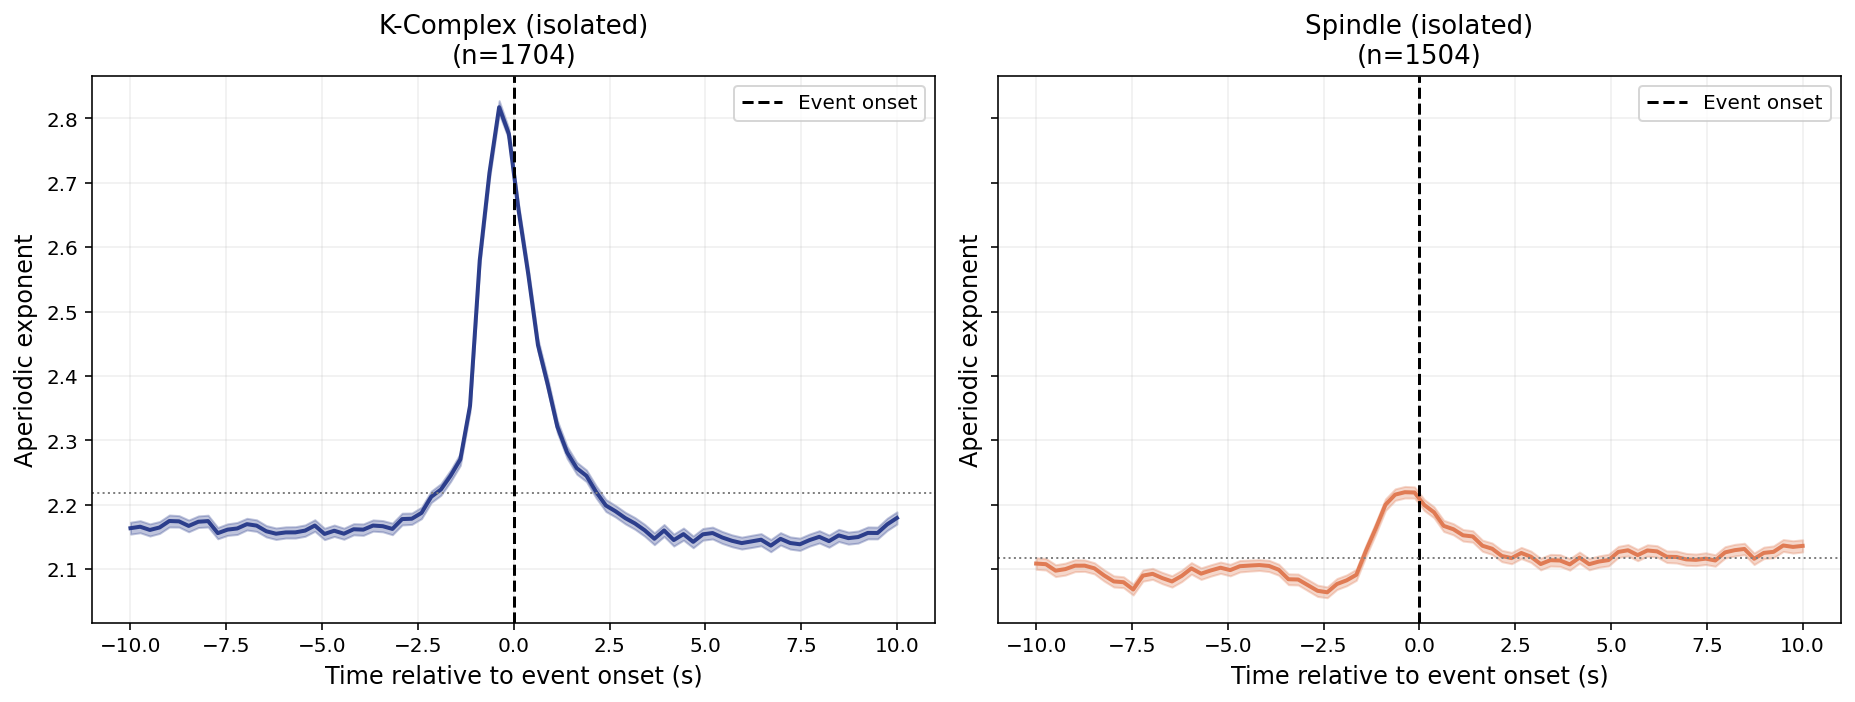

In [23]:
## Plot isolated event-locked exponent 

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, epochs, label, color in zip(
    axes,
    [kc_isolated_epochs, spindle_isolated_epochs],
    ["K-Complex (isolated)", "Spindle (isolated)"],
    ["#2c3e8c", "#e07b54"],
):
    mean = np.nanmean(epochs, axis=0)
    sem  = np.nanstd(epochs, axis=0) / np.sqrt(np.sum(~np.isnan(epochs), axis=0))

    ax.plot(t_event, mean, color=color, linewidth=2)
    ax.fill_between(t_event, mean - sem, mean + sem, alpha=0.3, color=color)
    ax.axvline(0, color="k", linestyle="--", linewidth=1.5, label="Event onset")
    ax.axhline(np.nanmean(mean), color="gray", linestyle=":", linewidth=1)
    ax.set_xlabel("Time relative to event onset (s)", fontsize=12)
    ax.set_ylabel("Aperiodic exponent", fontsize=12)
    ax.set_title(f"{label}\n(n={len(epochs)})", fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## Defining spindle trains 

Spindle train onset epochs (clean pre-window): 1143


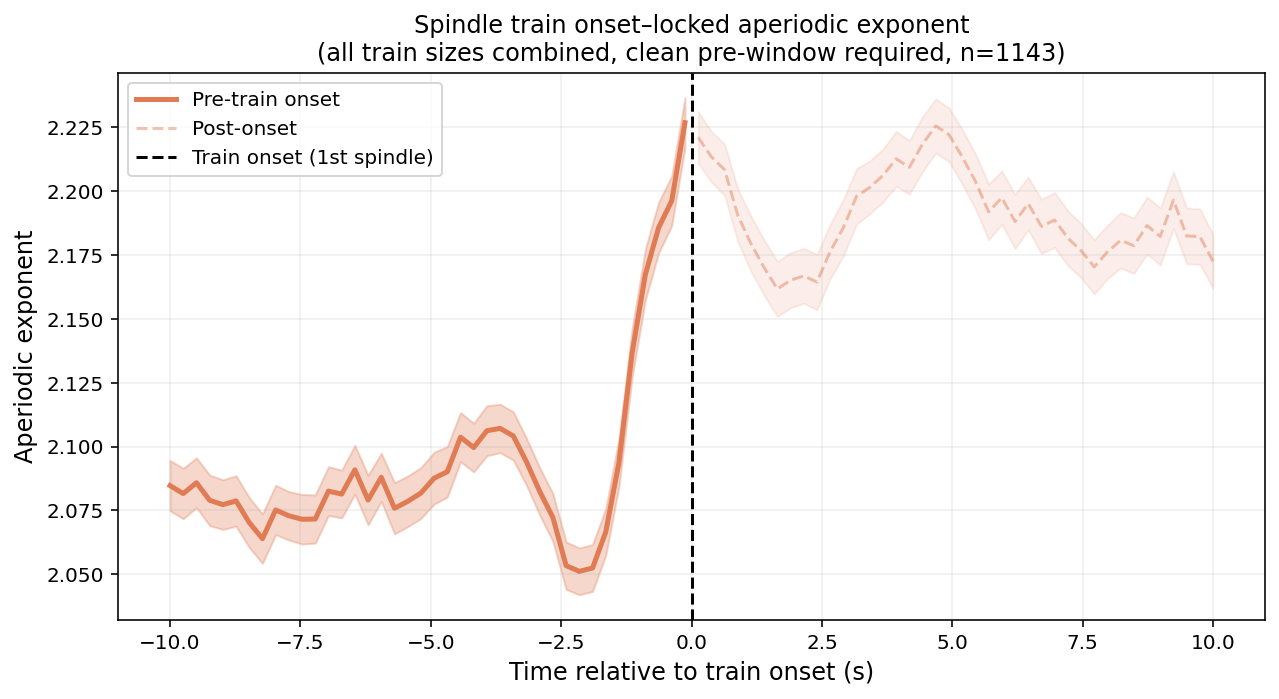

In [25]:
## Event-locked exponent at spindle TRAIN onset (all train sizes combined)
# Post-onset window is contaminated by the train itself, so focus on pre-onset dynamics.
# Pre-isolation: require no spindle or KC in the 10s before train onset.

pre_sec  = 10.0
post_sec = 10.0
n_bins   = int((pre_sec + post_sec) / step_sec)
t_event  = np.linspace(-pre_sec, post_sec, n_bins)

train_onset_epochs = []

# build a per-subject lookup of train onsets (is_train == True)
for subj_id, d in all_subjects.items():
    t_centers      = d["t_centers"]
    exponent_clean = d["exponent_clean"]
    kc_onsets      = d["kc_onsets"]
    spindle_onsets = d["spindle_onsets"]
    combined       = np.sort(np.concatenate([kc_onsets, spindle_onsets]))

    subj_trains = train_df[(train_df["subject"] == subj_id) & (train_df["is_train"])]

    for _, row in subj_trains.iterrows():
        onset = row["onset"]   # first spindle in the train

        # require clean pre-onset window: no events in (-pre_sec, 0)
        pre_events = combined[(combined < onset) & (combined >= onset - pre_sec)]
        if len(pre_events) > 0:
            continue

        mask = (t_centers >= onset - pre_sec) & (t_centers < onset + post_sec)
        seg  = exponent_clean[mask]

        if len(seg) != n_bins:
            continue
        if np.mean(np.isnan(seg)) > 0.2:
            continue

        train_onset_epochs.append(seg)

train_onset_epochs = np.array(train_onset_epochs)
print(f"Spindle train onset epochs (clean pre-window): {len(train_onset_epochs)}")

# plot
fig, ax = plt.subplots(figsize=(9, 5))

mean = np.nanmean(train_onset_epochs, axis=0)
sem  = np.nanstd(train_onset_epochs, axis=0) / np.sqrt(
           np.sum(~np.isnan(train_onset_epochs), axis=0))

# pre-onset: solid; post-onset: dashed + lighter (train contaminates post)
pre_mask  = t_event <= 0
post_mask = t_event >= 0

ax.plot(t_event[pre_mask],  mean[pre_mask],  color="#e07b54", linewidth=2.5, label="Pre-train onset")
ax.fill_between(t_event[pre_mask],
                mean[pre_mask] - sem[pre_mask],
                mean[pre_mask] + sem[pre_mask],
                alpha=0.3, color="#e07b54")

ax.plot(t_event[post_mask], mean[post_mask], color="#e07b54", linewidth=1.5,
        linestyle="--", alpha=0.45, label="Post-onset")
ax.fill_between(t_event[post_mask],
                mean[post_mask] - sem[post_mask],
                mean[post_mask] + sem[post_mask],
                alpha=0.12, color="#e07b54")

ax.axvline(0, color="k", linestyle="--", linewidth=1.5, label="Train onset (1st spindle)")
ax.set_xlabel("Time relative to train onset (s)", fontsize=12)
ax.set_ylabel("Aperiodic exponent", fontsize=12)
ax.set_title(f"Spindle train onset–locked aperiodic exponent\n"
             f"(all train sizes combined, clean pre-window required, n={len(train_onset_epochs)})",
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## baseline normalization 

In [26]:
## Stage-matched baseline normalization
# For each subject: compute mean exponent across all NREM2 windows that are
# event-free (>10s from any spindle or KC), then subtract that subject mean
# from every epoch before averaging.

N2_LABEL       = "Sleep stage 2"
#don't include events or surronding dynamics in baseline calculation 
event_excl_sec = 10.0   # exclusion radius around any event

subj_baseline = {}

for subj_id, d in all_subjects.items():
    t_centers      = d["t_centers"]
    exponent_clean = d["exponent_clean"]
    window_stages  = np.array(d["window_stages"])
    kc_onsets      = d["kc_onsets"]
    spindle_onsets = d["spindle_onsets"]
    combined       = np.sort(np.concatenate([kc_onsets, spindle_onsets]))

    # boolean mask: NREM2 and not within event_excl_sec of any event
    stage_mask = window_stages == N2_LABEL
    event_mask = np.ones(len(t_centers), dtype=bool)
    for ev in combined:
        event_mask &= np.abs(t_centers - ev) > event_excl_sec

    baseline_vals = exponent_clean[stage_mask & event_mask]
    baseline_vals = baseline_vals[~np.isnan(baseline_vals)]
    subj_baseline[subj_id] = np.mean(baseline_vals)
    #print(f"{subj_id}: N2 event-free windows = {(stage_mask & event_mask).sum()}, "
          #f"baseline mean = {subj_baseline[subj_id]:.4f}")

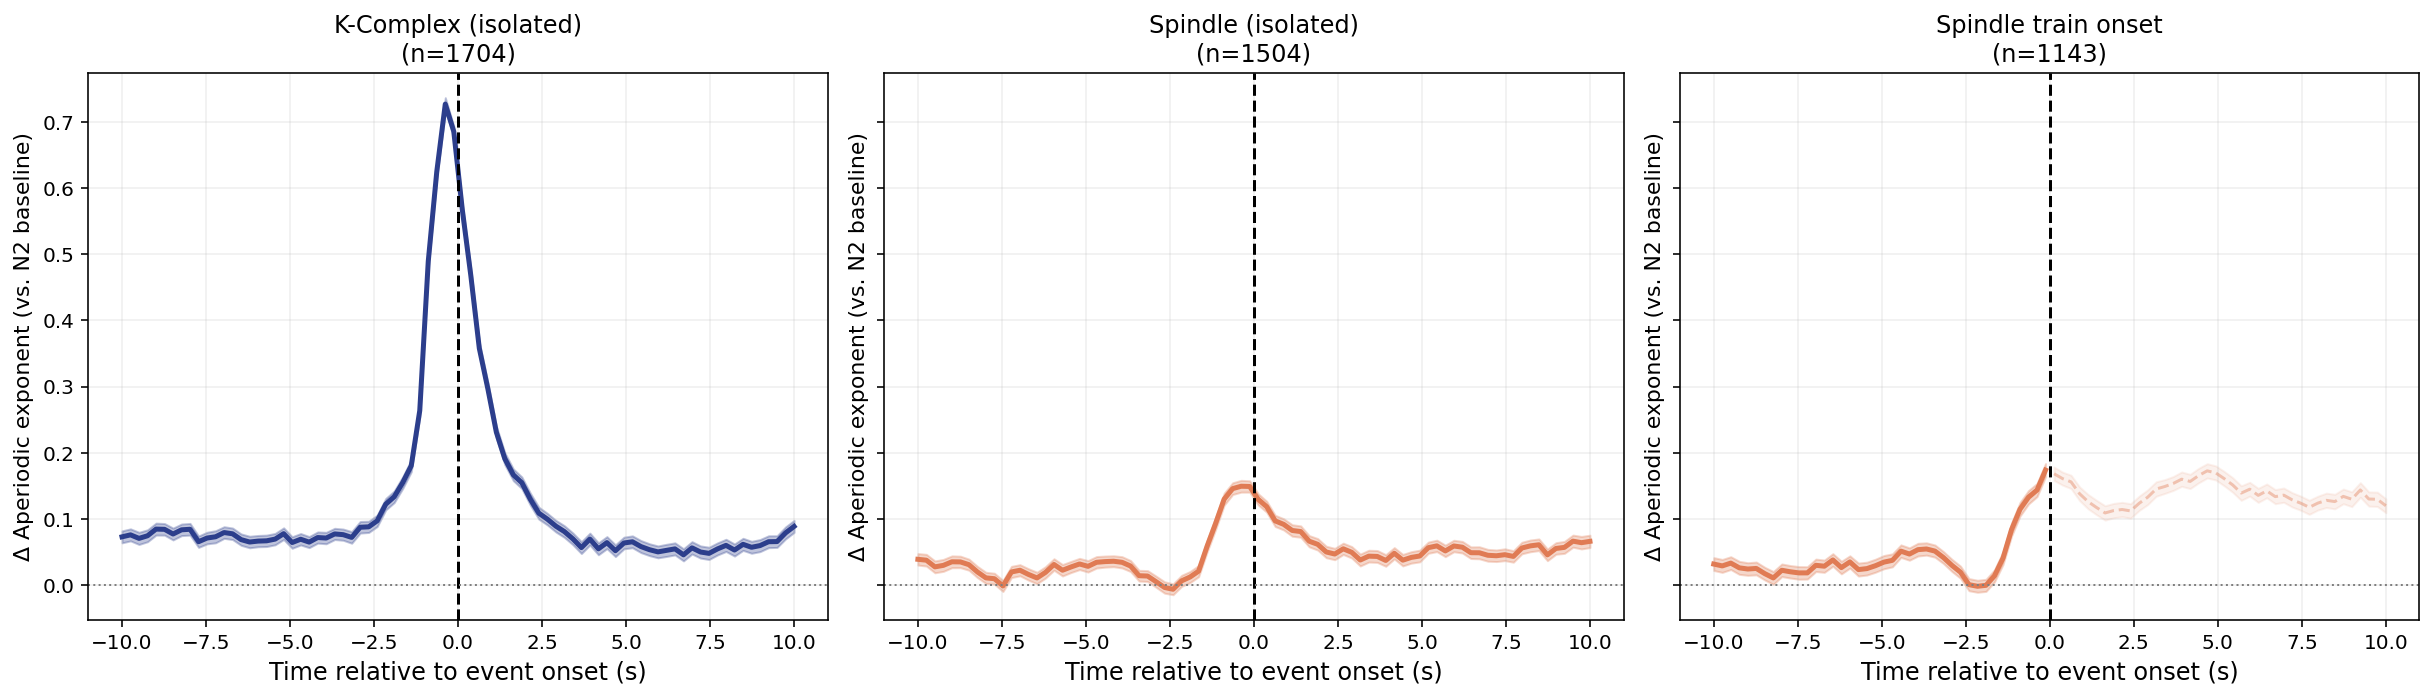

In [27]:
## Re-extract epochs with per-subject baseline subtracted
# Re-runs the epoch extraction from scratch so each epoch has its subject's
# NREM2 event-free mean removed before stacking.

pre_sec  = 10.0
post_sec = 10.0
n_bins   = int((pre_sec + post_sec) / step_sec)
t_event  = np.linspace(-pre_sec, post_sec, n_bins)
isolation_window = 10.0

kc_norm_epochs         = []
spindle_norm_epochs    = []
train_onset_norm_epochs = []

for subj_id, d in all_subjects.items():
    t_centers      = d["t_centers"]
    exponent_clean = d["exponent_clean"]
    kc_onsets      = d["kc_onsets"]
    spindle_onsets = d["spindle_onsets"]
    combined       = np.sort(np.concatenate([kc_onsets, spindle_onsets]))
    mu             = subj_baseline[subj_id]

    def extract(onset, require_clean_post=True):
        other = combined[combined != onset]
        if np.any(np.abs(other - onset) <= isolation_window):
            return None
        mask = (t_centers >= onset - pre_sec) & (t_centers < onset + post_sec)
        seg  = exponent_clean[mask] - mu          # subtract subject baseline
        if len(seg) != n_bins:
            return None
        if np.mean(np.isnan(seg)) > 0.2:
            return None
        return seg

    # isolated KCs
    for onset in kc_onsets:
        seg = extract(onset)
        if seg is not None:
            kc_norm_epochs.append(seg)

    # isolated spindles
    for onset in spindle_onsets:
        seg = extract(onset)
        if seg is not None:
            spindle_norm_epochs.append(seg)

    # spindle train onsets (clean pre-window only)
    subj_trains = train_df[(train_df["subject"] == subj_id) & (train_df["is_train"])]
    for _, row in subj_trains.iterrows():
        onset = row["onset"]
        pre_events = combined[(combined < onset) & (combined >= onset - pre_sec)]
        if len(pre_events) > 0:
            continue
        mask = (t_centers >= onset - pre_sec) & (t_centers < onset + post_sec)
        seg  = exponent_clean[mask] - mu
        if len(seg) != n_bins or np.mean(np.isnan(seg)) > 0.2:
            continue
        train_onset_norm_epochs.append(seg)

kc_norm_epochs          = np.array(kc_norm_epochs)
spindle_norm_epochs     = np.array(spindle_norm_epochs)
train_onset_norm_epochs = np.array(train_onset_norm_epochs)

# plot difference events (Kc, spindle, spindle trains)
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

configs = [
    (kc_norm_epochs,          "K-Complex (isolated)",      "#2c3e8c", False),
    (spindle_norm_epochs,     "Spindle (isolated)",         "#e07b54", False),
    (train_onset_norm_epochs, "Spindle train onset",        "#e07b54", True),
]

#make post event onset in spindle trains lighter -> this is recordings DURING spindle train so should not interpret dynamics 
for ax, (epochs, label, color, train_flag) in zip(axes, configs):
    mean = np.nanmean(epochs, axis=0)
    sem  = np.nanstd(epochs,  axis=0) / np.sqrt(np.sum(~np.isnan(epochs), axis=0))

    if train_flag:
        pre_m  = t_event <= 0
        post_m = t_event >= 0
        ax.plot(t_event[pre_m],  mean[pre_m],  color=color, linewidth=2.5)
        ax.fill_between(t_event[pre_m],
                        mean[pre_m] - sem[pre_m], mean[pre_m] + sem[pre_m],
                        alpha=0.3, color=color)
        ax.plot(t_event[post_m], mean[post_m], color=color, linewidth=1.5,
                linestyle="--", alpha=0.4)
        ax.fill_between(t_event[post_m],
                        mean[post_m] - sem[post_m], mean[post_m] + sem[post_m],
                        alpha=0.1, color=color)
    else:
        ax.plot(t_event, mean, color=color, linewidth=2.5)
        ax.fill_between(t_event, mean - sem, mean + sem, alpha=0.3, color=color)

    ax.axvline(0, color="k", linestyle="--", linewidth=1.5)
    ax.axhline(0, color="gray", linestyle=":", linewidth=1)
    ax.set_xlabel("Time relative to event onset (s)", fontsize=12)
    ax.set_ylabel("Δ Aperiodic exponent (vs. N2 baseline)", fontsize=11)
    ax.set_title(f"{label}\n(n={len(epochs)})", fontsize=12)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## DETECTOR AND EXPERT OVERLAP -> K complexes 

In [14]:
## IS there a difference across what MTKCD and experts classify as events based on pre event dynamics? 

MTKCD_DIR = Path("/Users/elizabethkaplan/Desktop/SS2_Results/New/mtkcd_results")
#mtkcd detections from run_mtkcd_cleaned.ipynb
mtkcd_df  = pd.read_csv(MTKCD_DIR / "mtkcd_all_detections.csv")

step_sec = float(np.median(np.diff(all_subjects["01-02-0001"]["t_centers"])))
print(f"step_sec = {step_sec:.4f}s")

MATCH_TOL      = 1.0
isolation_window = 10.0
pre_sec  = 10.0
post_sec = 10.0
n_bins   = int((pre_sec + post_sec) / step_sec)
t_event  = np.linspace(-pre_sec, post_sec, n_bins)

both_epochs        = []
expert_only_epochs = []

for subj_id, d in all_subjects.items():
    t_centers      = d["t_centers"]
    exponent_clean = d["exponent_clean"]
    kc_onsets      = d["kc_onsets"]
    spindle_onsets = d["spindle_onsets"]
    combined       = np.sort(np.concatenate([kc_onsets, spindle_onsets]))
    mu             = subj_baseline[subj_id]

    subj_mtkcd = mtkcd_df[mtkcd_df["subject"] == subj_id]["Start"].to_numpy()

    for onset in kc_onsets:
        # same isolation requirement as the rest of the analysis
        other = combined[combined != onset]
        if np.any(np.abs(other - onset) <= isolation_window):
            continue

        mask = (t_centers >= onset - pre_sec) & (t_centers < onset + post_sec)
        seg  = exponent_clean[mask] - mu
        if len(seg) != n_bins or np.mean(np.isnan(seg)) > 0.2:
            continue
        #if event is marked by both expert and MTKCD, add to both_epochs 
        if len(subj_mtkcd) > 0 and np.any(np.abs(subj_mtkcd - onset) <= MATCH_TOL):
            both_epochs.append(seg)
        else:
            expert_only_epochs.append(seg)

both_epochs        = np.array(both_epochs)
expert_only_epochs = np.array(expert_only_epochs)

#print(f"Algorithm-confirmed KCs (both):  {len(both_epochs)}")
#print(f"Expert-only KCs:                 {len(expert_only_epochs)}")

step_sec = 0.2500s
Algorithm-confirmed KCs (both):  664
Expert-only KCs:                 1040


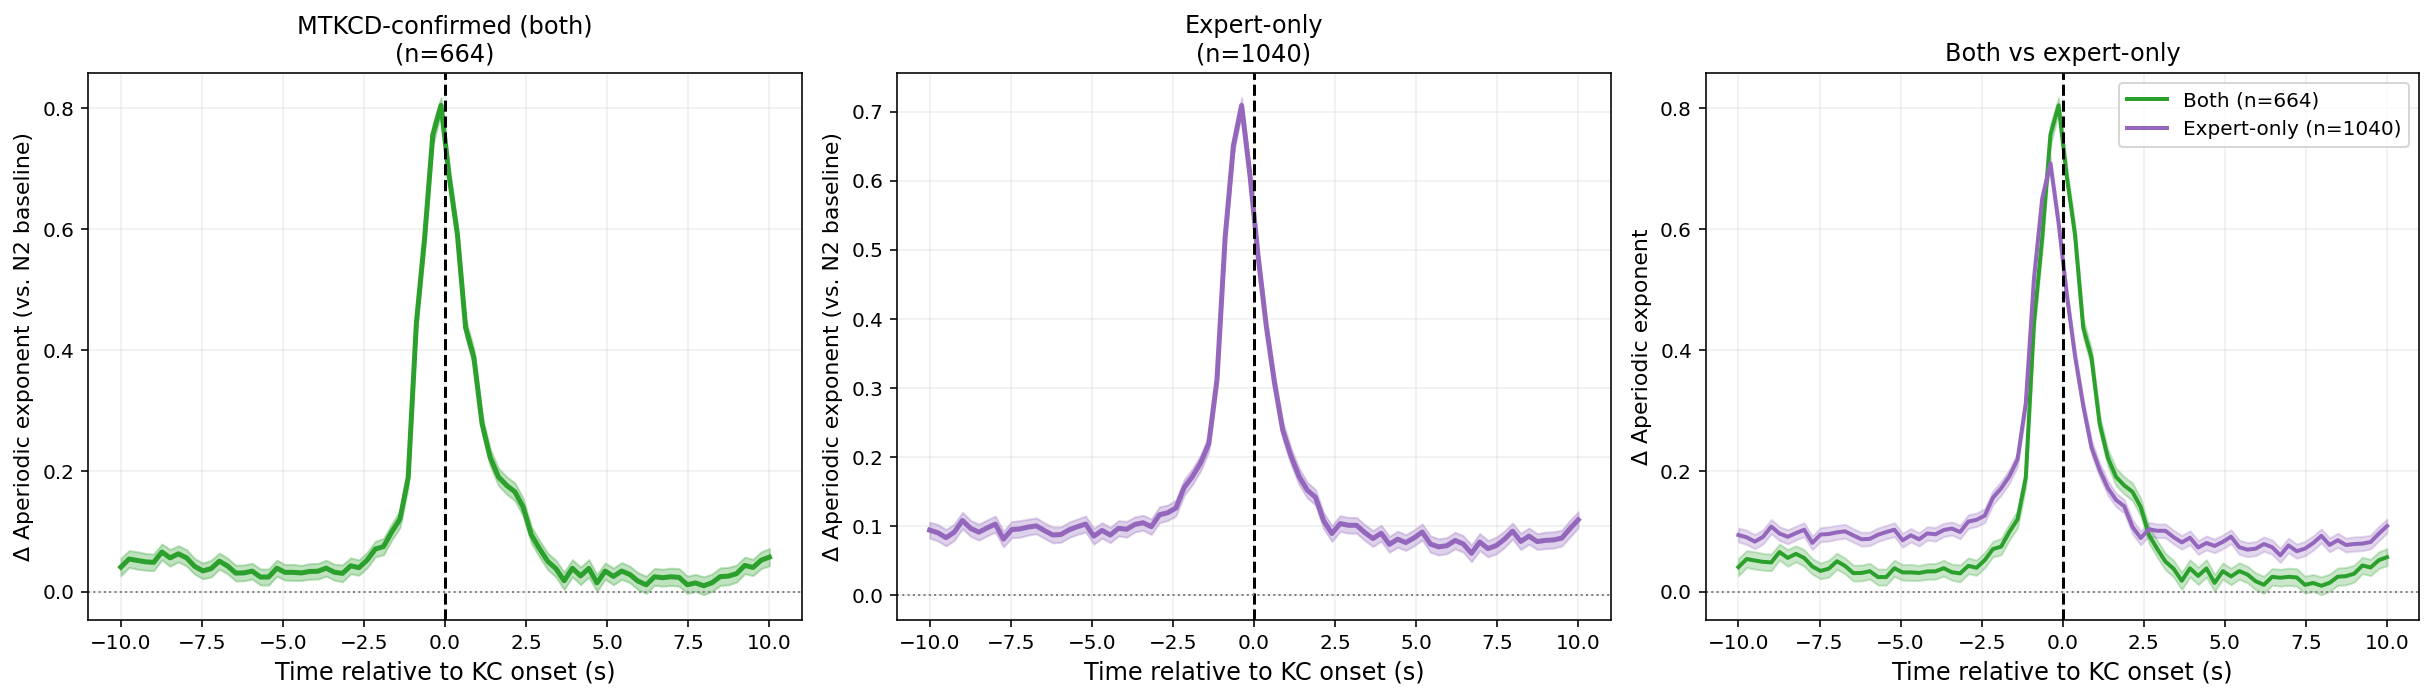

In [29]:
#plot time resolved dynamics to see if there are differences in pre-event dynamics 
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# plot expert vs MTKCD detections 
for ax, epochs, label, color in zip(
    axes[:2],
    [both_epochs, expert_only_epochs],
    ["MTKCD-confirmed (both)", "Expert-only"],
    ["#2ca02c", "#9467bd"],
):
    mean = np.nanmean(epochs, axis=0)
    sem  = np.nanstd(epochs,  axis=0) / np.sqrt(np.sum(~np.isnan(epochs), axis=0))
    ax.plot(t_event, mean, color=color, linewidth=2.5)
    ax.fill_between(t_event, mean - sem, mean + sem, alpha=0.3, color=color)
    ax.axvline(0, color="k", linestyle="--", linewidth=1.5)
    ax.axhline(0, color="gray", linestyle=":", linewidth=1)
    ax.set_xlabel("Time relative to KC onset (s)", fontsize=12)
    ax.set_ylabel("Δ Aperiodic exponent (vs. N2 baseline)", fontsize=11)
    ax.set_title(f"{label}\n(n={len(epochs)})", fontsize=12)
    ax.grid(True, alpha=0.2)

# both events overlaid 
ax = axes[2]
mean_b = np.nanmean(both_epochs,        axis=0)
sem_b  = np.nanstd(both_epochs,         axis=0) / np.sqrt(len(both_epochs))
mean_e = np.nanmean(expert_only_epochs, axis=0)
sem_e  = np.nanstd(expert_only_epochs,  axis=0) / np.sqrt(len(expert_only_epochs))

ax.plot(t_event, mean_b, color="#2ca02c", linewidth=2, label=f"Both (n={len(both_epochs)})")
ax.fill_between(t_event, mean_b - sem_b, mean_b + sem_b, alpha=0.25, color="#2ca02c")
ax.plot(t_event, mean_e, color="#9467bd", linewidth=2, label=f"Expert-only (n={len(expert_only_epochs)})")
ax.fill_between(t_event, mean_e - sem_e, mean_e + sem_e, alpha=0.25, color="#9467bd")

ax.axvline(0, color="k", linestyle="--", linewidth=1.5)
ax.axhline(0, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Time relative to KC onset (s)", fontsize=12)
ax.set_ylabel("Δ Aperiodic exponent", fontsize=11)
ax.set_title("Both vs expert-only", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## classiffy only MT-KCD confirmed KCs and then examine preevent dynamics 

In [30]:
# Look at the aperiodic dynamics preceding events confirmed by BOTH expert and MTKCD
before_spindle_epochs = []
isolated_epochs       = []

for subj_id, d in all_subjects.items():
    t_centers      = d["t_centers"]
    exponent_clean = d["exponent_clean"]
    kc_onsets      = d["kc_onsets"]
    spindle_onsets = d["spindle_onsets"]
    combined       = np.sort(np.concatenate([kc_onsets, spindle_onsets]))
    mu             = subj_baseline[subj_id]

    subj_mtkcd = mtkcd_df[mtkcd_df["subject"] == subj_id]["Start"].to_numpy()
    if len(subj_mtkcd) == 0:
        continue

    subj_rel = relation_df[
        (relation_df["subject"] == subj_id) &
        (relation_df["event_type"] == "kc") &
        (relation_df["category"].isin(["kc_before_spindle", "kc_isolated"]))
    ]
    #match events marked by both 
    for _, rel_row in subj_rel.iterrows():
        expert_onset = rel_row["onset"]
        category     = rel_row["category"]

        diffs = subj_mtkcd - expert_onset
        idx   = np.argmin(np.abs(diffs))
        if np.abs(diffs[idx]) > MATCH_TOL:
            continue

        mtkcd_onset = subj_mtkcd[idx]
        other       = combined[np.abs(combined - expert_onset) > 0.01]

        if category == "kc_isolated":
            if np.any(np.abs(other - mtkcd_onset) <= isolation_window):
                continue
        else:
            if np.any((other < mtkcd_onset) & (other >= mtkcd_onset - pre_sec)):
                continue

        mask = (t_centers >= mtkcd_onset - pre_sec) & (t_centers < mtkcd_onset + post_sec)
        seg  = exponent_clean[mask] - mu
        if len(seg) != n_bins or np.mean(np.isnan(seg)) > 0.2:
            continue

        if category == "kc_before_spindle":
            before_spindle_epochs.append(seg)
        else:
            isolated_epochs.append(seg)

#before_spindle_epochs = np.array(before_spindle_epochs)
#isolated_epochs       = np.array(isolated_epochs)

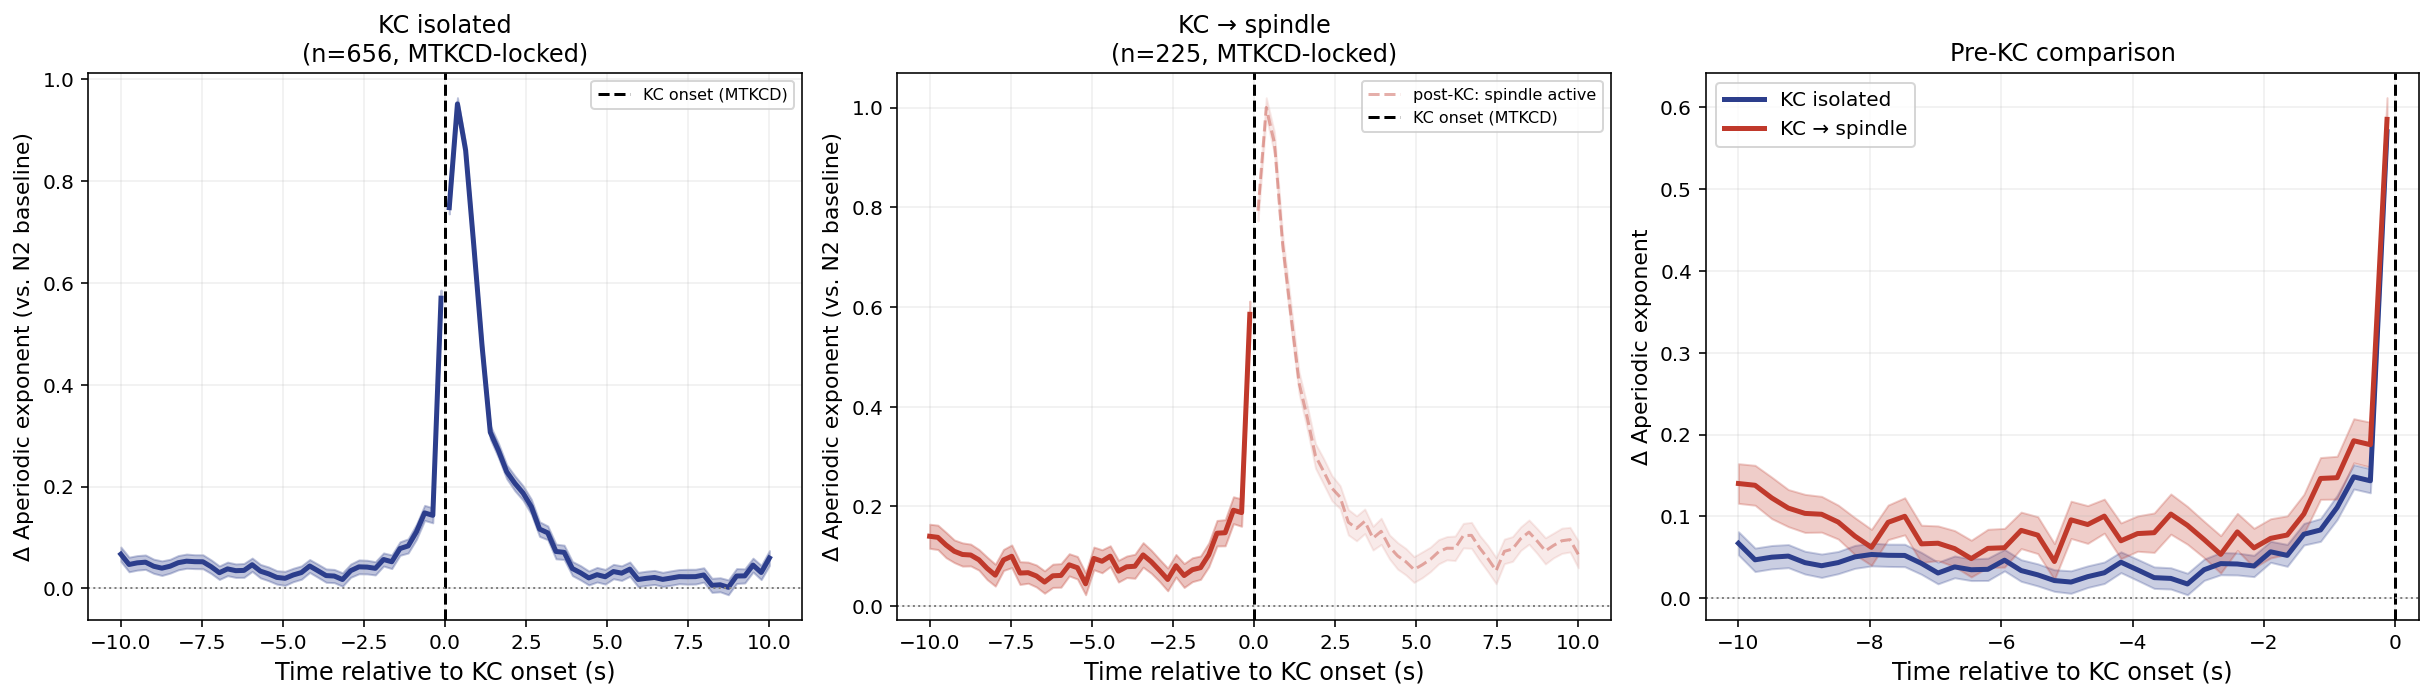

In [21]:
## plot dynamics leading up to isolated vs pre spindle KCs -- only events confirmed by both experts and alg
#is there a difference in dynamics across these two events?

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

configs = [
    (isolated_epochs,       "KC isolated",       "#2c3e8c", False),
    (before_spindle_epochs, "KC → spindle",       "#c0392b", True),
]

for ax, (epochs, label, color, contaminated_post) in zip(axes[:2], configs):
    mean = np.nanmean(epochs, axis=0)
    sem  = np.nanstd(epochs,  axis=0) / np.sqrt(np.sum(~np.isnan(epochs), axis=0))
    pre_m  = t_event <= 0
    post_m = t_event >= 0

    ax.plot(t_event[pre_m], mean[pre_m], color=color, linewidth=2.5)
    ax.fill_between(t_event[pre_m], mean[pre_m]-sem[pre_m], mean[pre_m]+sem[pre_m],
                    alpha=0.3, color=color)
    #seperates event's based on "contamination" i.e. whether spindle follows KC 
    lw_post = 1.5 if contaminated_post else 2.5
    al_post = 0.4 if contaminated_post else 1.0
    ls_post = "--" if contaminated_post else "-"
    ax.plot(t_event[post_m], mean[post_m], color=color, linewidth=lw_post,
            linestyle=ls_post, alpha=al_post,
            label="post-KC: spindle active" if contaminated_post else None)
    ax.fill_between(t_event[post_m], mean[post_m]-sem[post_m], mean[post_m]+sem[post_m],
                    alpha=0.1 if contaminated_post else 0.3, color=color)
    #plots events seperately 
    ax.axvline(0, color="k", linestyle="--", linewidth=1.5, label="KC onset (MTKCD)")
    ax.axhline(0, color="gray", linestyle=":", linewidth=1)
    ax.set_xlabel("Time relative to KC onset (s)", fontsize=12)
    ax.set_ylabel("Δ Aperiodic exponent (vs. N2 baseline)", fontsize=11)
    ax.set_title(f"{label}\n(n={len(epochs)}, MTKCD-locked)", fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

# overlaid comparison -> pre event dynamics 
ax = axes[2]
for epochs, label, color in [
    (isolated_epochs,       "KC isolated", "#2c3e8c"),
    (before_spindle_epochs, "KC → spindle","#c0392b"),
]:
    mean = np.nanmean(epochs, axis=0)
    sem  = np.nanstd(epochs,  axis=0) / np.sqrt(np.sum(~np.isnan(epochs), axis=0))
    ax.plot(t_event[t_event<=0], mean[t_event<=0], color=color, linewidth=2.5, label=label)
    ax.fill_between(t_event[t_event<=0],
                    mean[t_event<=0]-sem[t_event<=0],
                    mean[t_event<=0]+sem[t_event<=0],
                    alpha=0.25, color=color)

ax.axvline(0, color="k", linestyle="--", linewidth=1.5)
ax.axhline(0, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Time relative to KC onset (s)", fontsize=12)
ax.set_ylabel("Δ Aperiodic exponent", fontsize=11)
ax.set_title("Pre-KC comparison", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

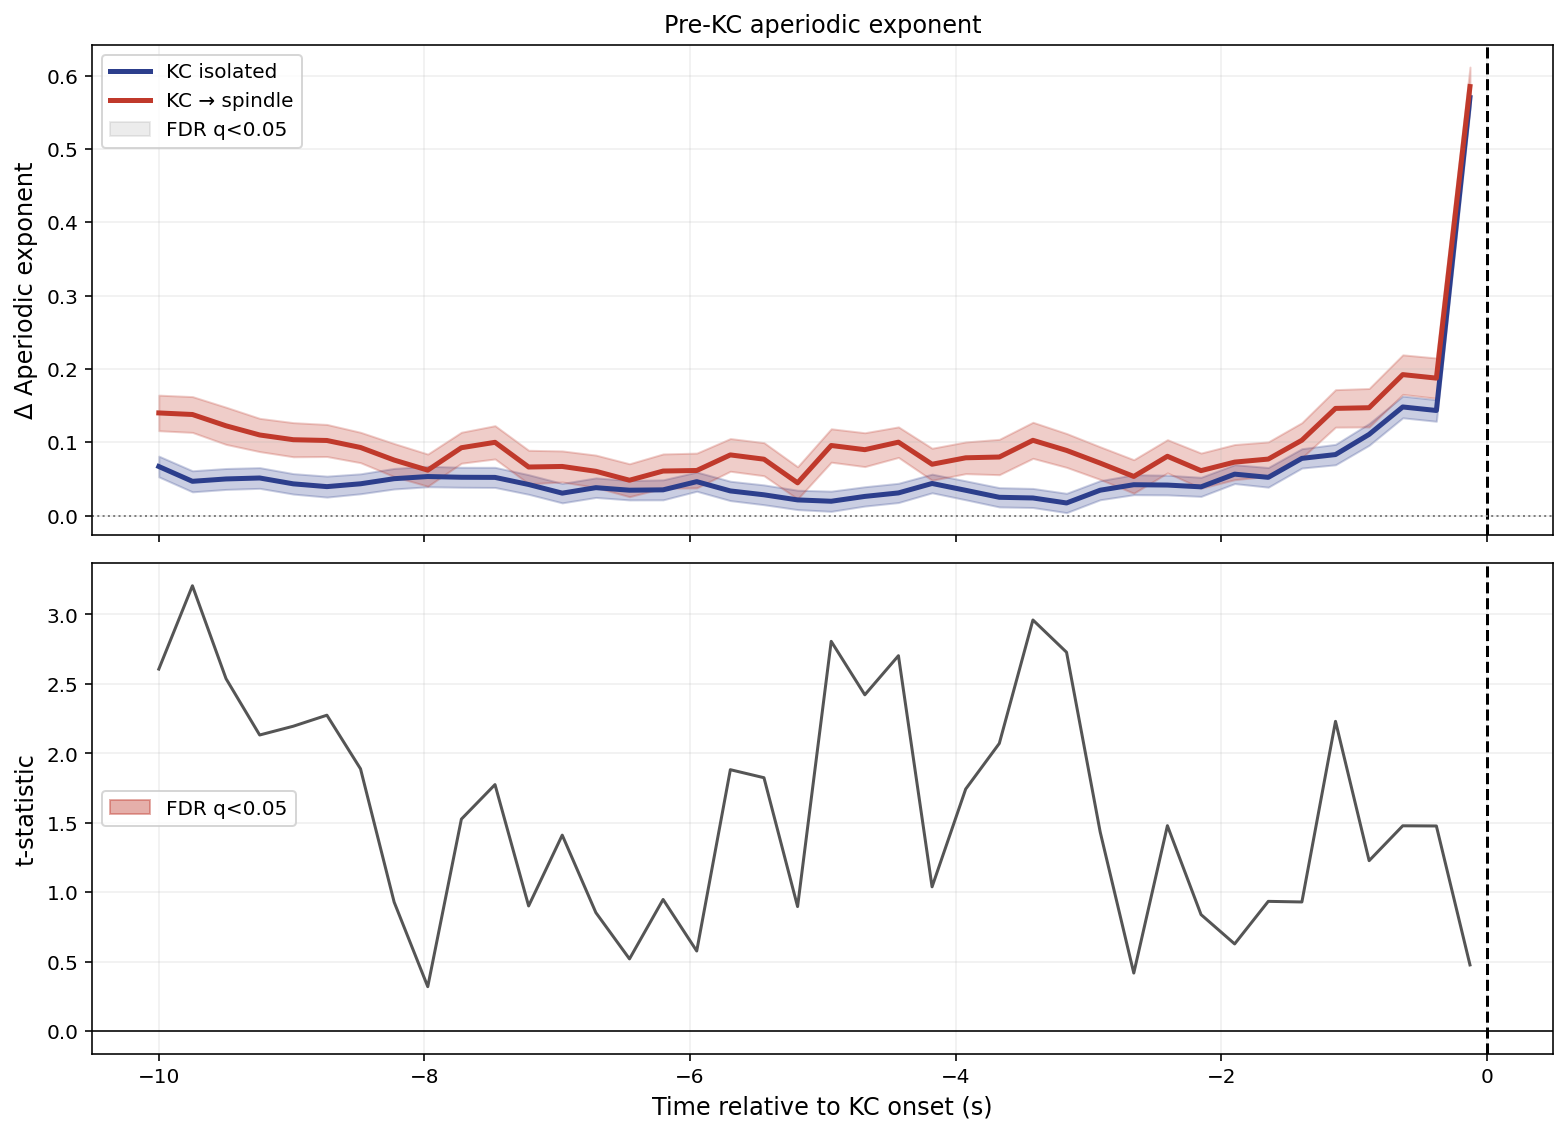

In [32]:
# extract pre timing
pre_mask = t_event <= 0
t_pre    = t_event[pre_mask]
pre_idx  = np.where(pre_mask)[0]

#convert to array for stats 
before_spindle_epochs = np.array(before_spindle_epochs)
isolated_epochs       = np.array(isolated_epochs)

# point-wise independent t-test across pre-window
t_stats = []
p_vals  = []
for ti in pre_idx:
    a = before_spindle_epochs[:, ti]; a = a[~np.isnan(a)]
    b = isolated_epochs[:, ti];       b = b[~np.isnan(b)]
    t, p = ttest_ind(a, b) if (len(a) > 1 and len(b) > 1) else (np.nan, np.nan)
    t_stats.append(t)
    p_vals.append(p)

t_stats = np.array(t_stats)
p_vals  = np.array(p_vals)

# FDR correction
_, p_fdr, _, _ = multipletests(p_vals[~np.isnan(p_vals)], method="fdr_bh")
p_corrected = np.full_like(p_vals, np.nan)
p_corrected[~np.isnan(p_vals)] = p_fdr
sig_fdr = p_corrected < 0.05

# plot
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# top: timeseries comparison
ax = axes[0]
for epochs, label, color in [
    (isolated_epochs,       "KC isolated",  "#2c3e8c"),
    (before_spindle_epochs, "KC → spindle", "#c0392b"),
]:
    mean = np.nanmean(epochs[:, pre_idx], axis=0)
    sem  = np.nanstd(epochs[:, pre_idx],  axis=0) / np.sqrt(np.sum(~np.isnan(epochs[:, pre_idx]), axis=0))
    ax.plot(t_pre, mean, color=color, linewidth=2.5, label=label)
    ax.fill_between(t_pre, mean - sem, mean + sem, alpha=0.25, color=color)

ax.fill_between(t_pre, *ax.get_ylim(), where=sig_fdr,
                alpha=0.15, color="gray", label="FDR q<0.05")
ax.axvline(0, color="k", linestyle="--", linewidth=1.5)
ax.axhline(0, color="gray", linestyle=":", linewidth=1)
ax.set_ylabel("Δ Aperiodic exponent", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
ax.set_title("Pre-KC aperiodic exponent", fontsize=12)

# bottom: t-statistic trace
ax = axes[1]
ax.plot(t_pre, t_stats, color="#555", linewidth=1.5)
ax.fill_between(t_pre, 0, t_stats, where=sig_fdr,
                alpha=0.4, color="#c0392b", label="FDR q<0.05")
ax.axhline(0, color="k", linewidth=0.8)
ax.axvline(0, color="k", linestyle="--", linewidth=1.5)
ax.set_xlabel("Time relative to KC onset (s)", fontsize=12)
ax.set_ylabel("t-statistic", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()